In [2]:
import csv
import math
import regex
import os

Processing log file: path_071_log_1.csv


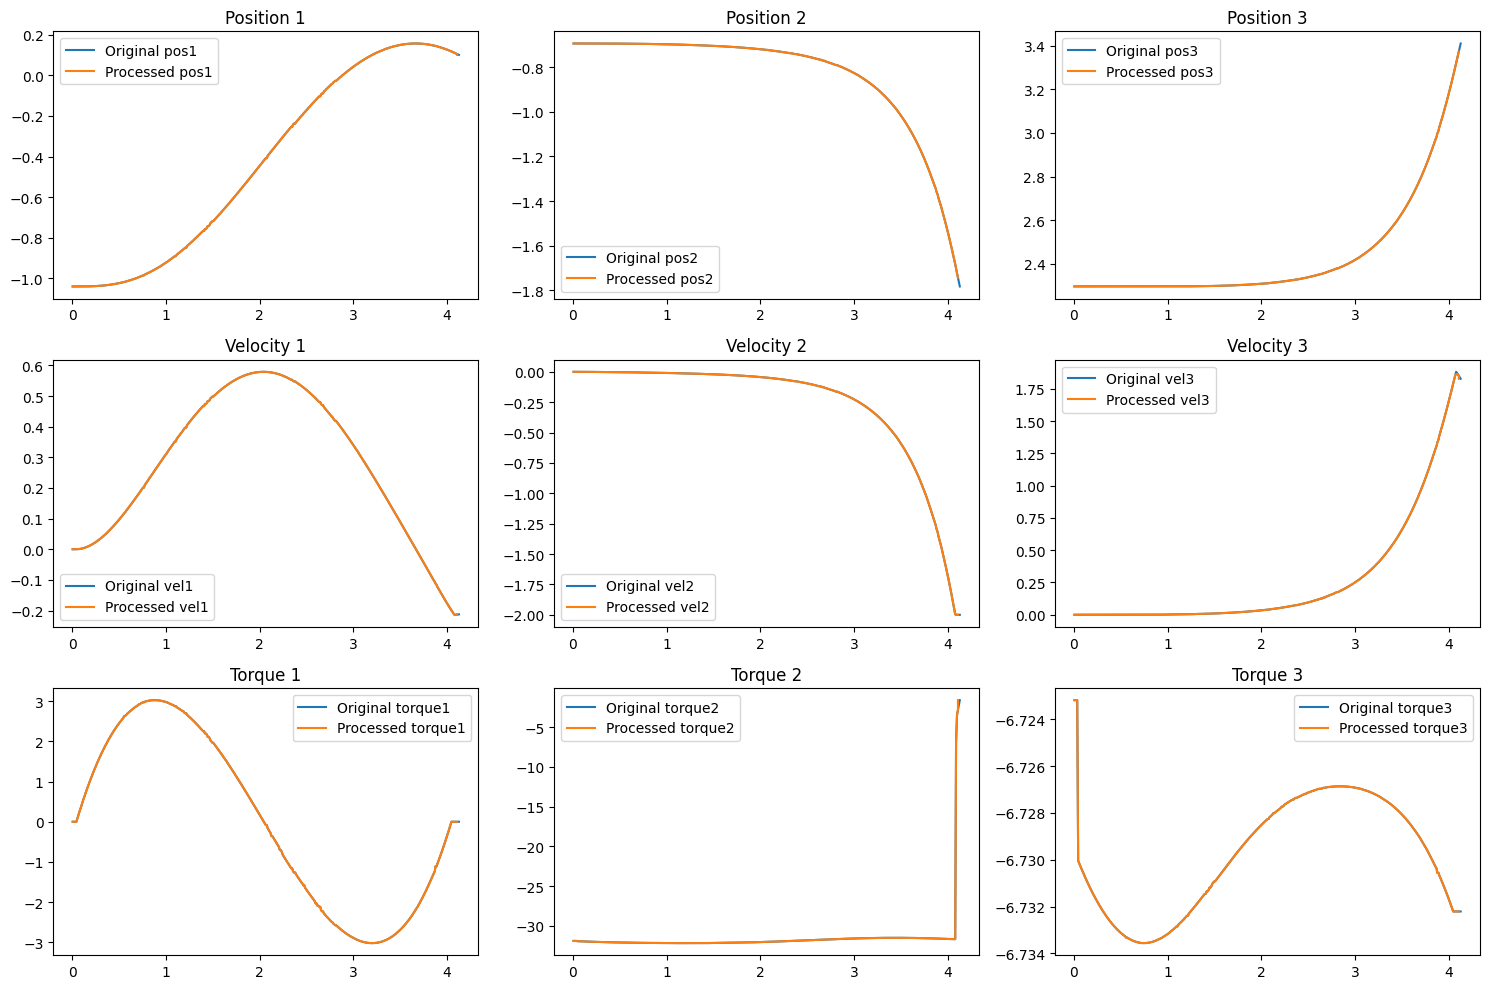

Processing log file: path_072_log_1.csv


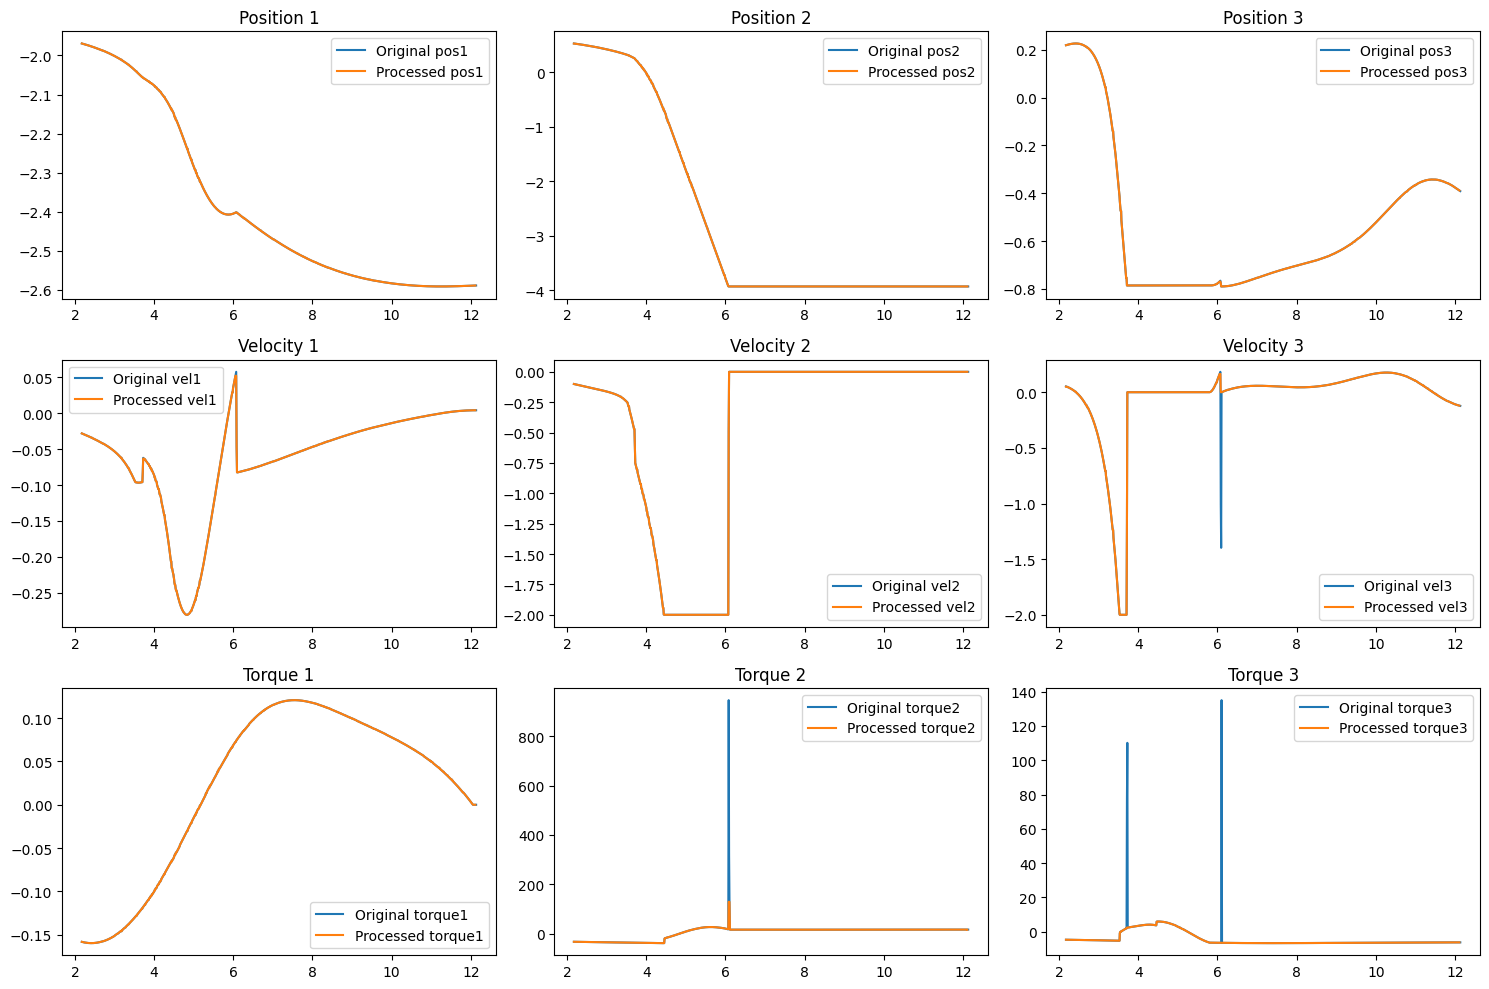

Processing log file: path_073_log_1.csv


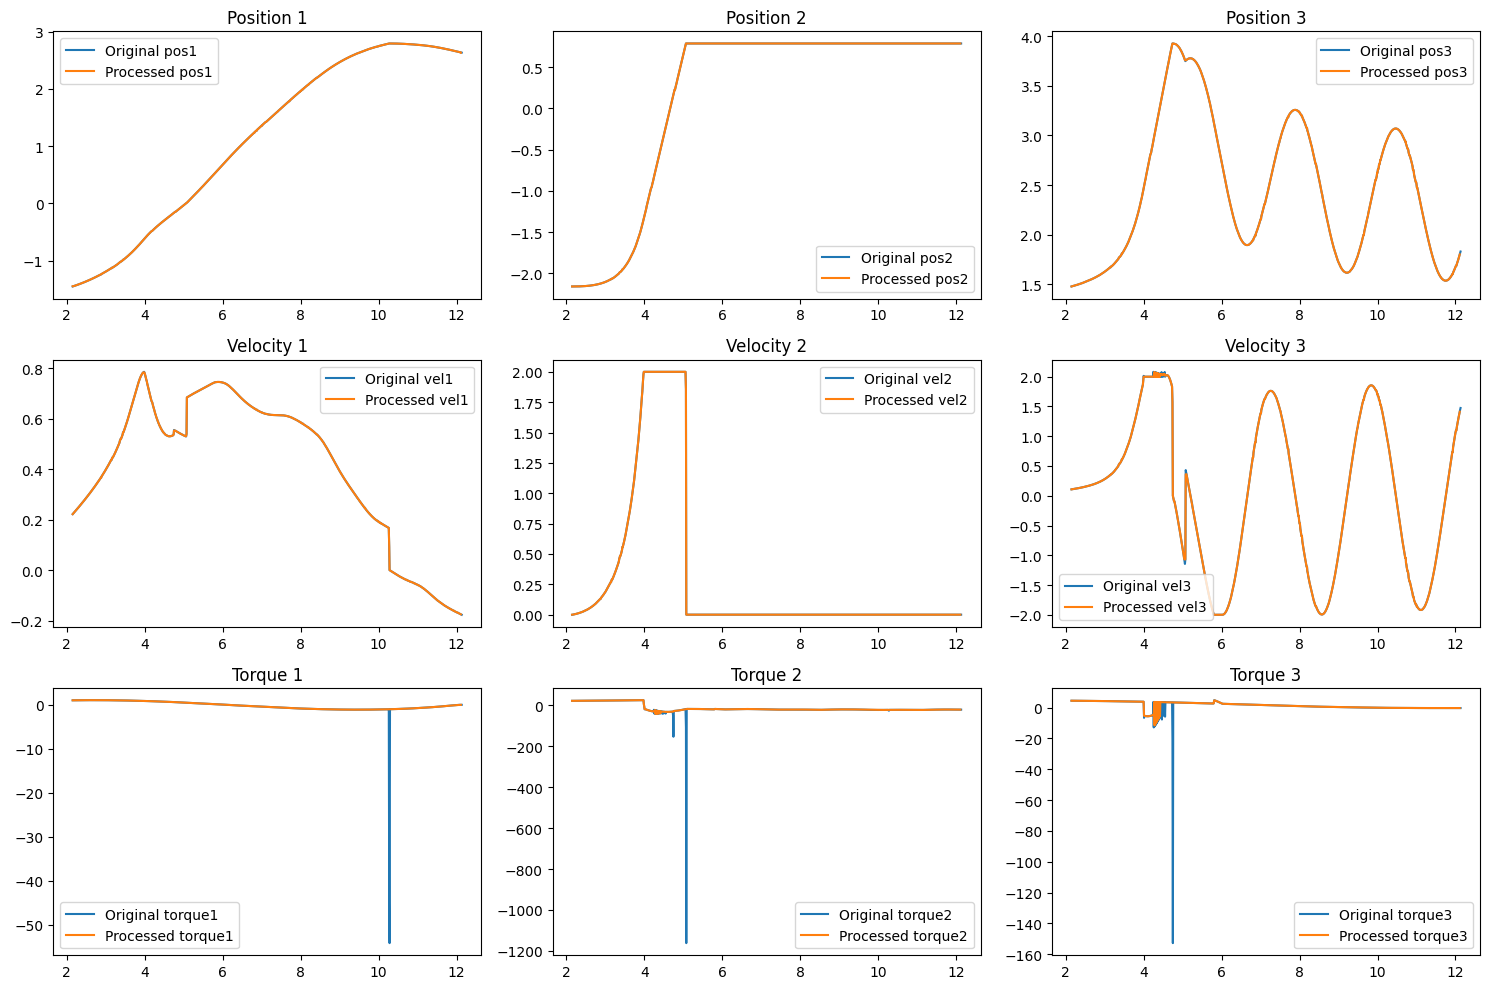

Processing log file: path_070_log_2.csv


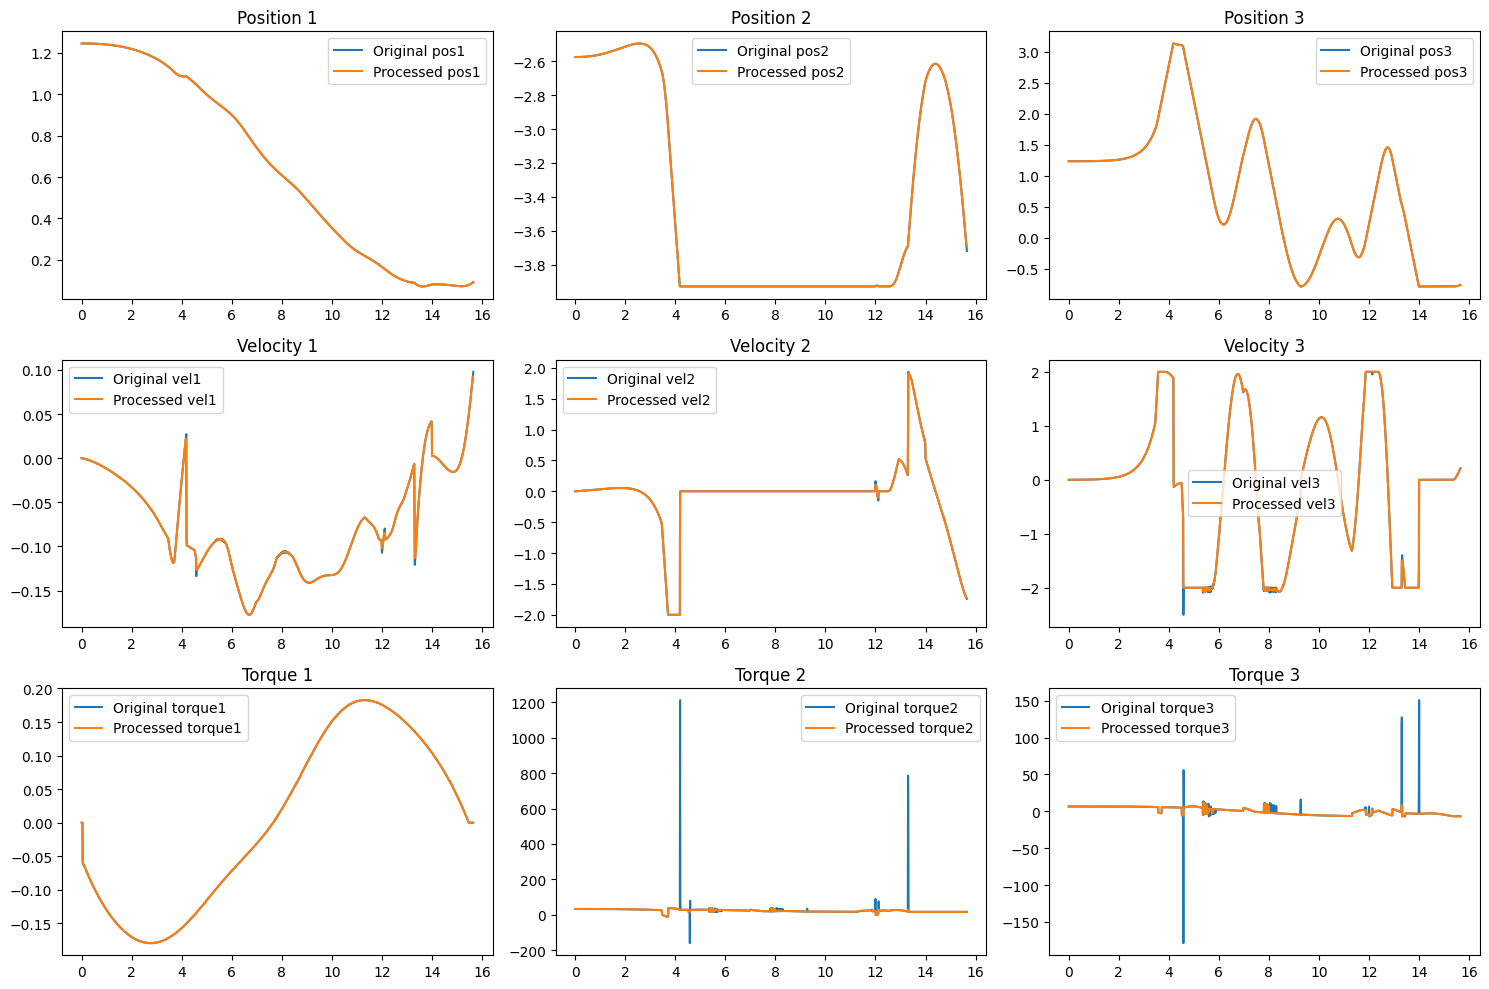

Processing log file: path_070_log_1.csv


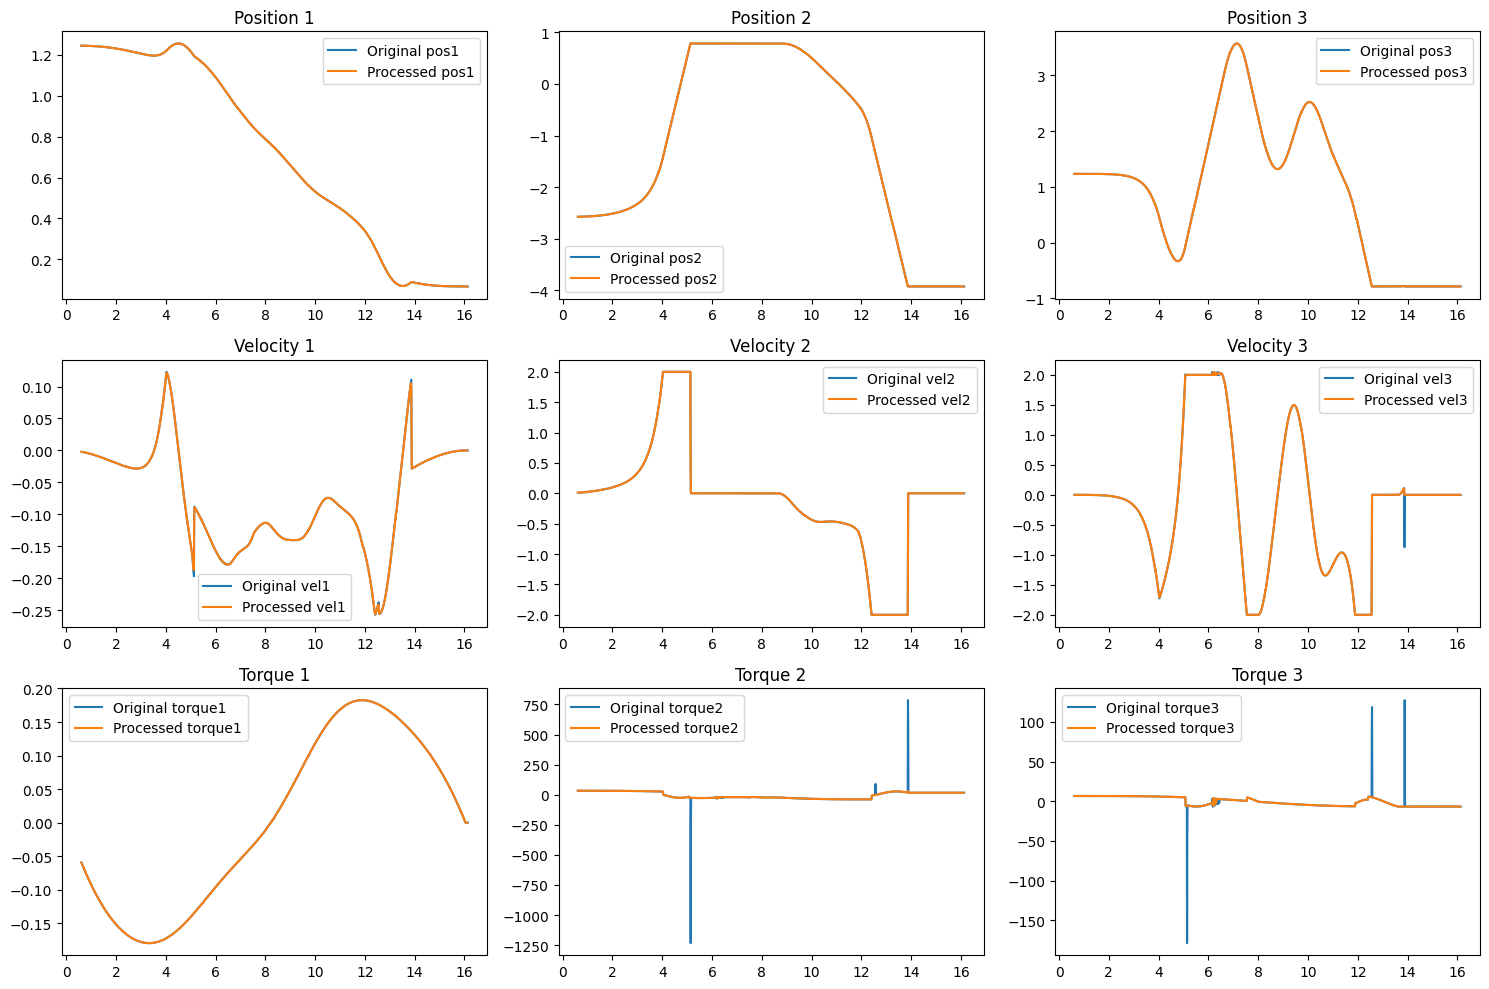

In [ ]:
from time import time

import pandas as pd
import re
import os
import numpy as np
from scipy.signal import medfilt, savgol_filter

# Read the CSV into a DataFrame
log_dir_path = '/data/ros2/ros2_ws2/arm_bot/src/scripts/logs'
dataset_dir_path = '/data/ros2/ros2_ws2/arm_bot/src/scripts/Joint_states'
new_dataset_dir_path = '/data/ros2/ros2_ws2/arm_bot/src/scripts/new_generatedDataset'


def smart_filter(x):
    # remove spikes
    x1 = medfilt(x, kernel_size=5)

    # smooth curve while preserving shape
    x2 = savgol_filter(x1, window_length=11, polyorder=3)

    return x2


for filename in os.listdir(log_dir_path):
    match = re.search(r'path_(\d+)_log_(\d+)\.csv$', filename)
    if match and int(match.group(1)) >= 70 and int(match.group(1)) <= 73:
        log_file_path = os.path.join(log_dir_path, filename)
        print(f'Processing log file: {filename}')

        df = pd.read_csv(log_file_path)

        time = df['time_elapsed'].tolist()
        pos1 = df['pos1'].tolist()
        pos2 = df['pos2'].tolist()
        pos3 = df['pos3'].tolist()
        vel1 = df['vel1'].tolist()
        vel2 = df['vel2'].tolist()
        vel3 = df['vel3'].tolist()
        tau1 = df['torque1'].tolist()
        tau2 = df['torque2'].tolist()
        tau3 = df['torque3'].tolist()

        time, pos1, pos2, pos3, vel1, vel2, vel3, tau1, tau2, tau3 = map(smart_filter, [time, pos1, pos2, pos3, vel1, vel2, vel3, tau1, tau2, tau3])
        
        df1 = pd.DataFrame({
            'time_elapsed': time,
            'pos1': pos1,
            'pos2': pos2,
            'pos3': pos3,
            'vel1': vel1,
            'vel2': vel2,
            'vel3': vel3,
            'torque1': tau1,
            'torque2': tau2,
            'torque3': tau3
        })

        # add acceleration fields by calculating the difference between consecutive velocity values and filling the first value with 0.
        df1['da1'] = df1['vel1'].diff().fillna(0).round(6)  # da1
        df1['da2'] = df1['vel2'].diff().fillna(0).round(6)  # da2
        df1['da3'] = df1['vel3'].diff().fillna(0).round(6)  # da3

        # Rename the columns to match your desired header names
        df1 = df1.rename(columns={
            'time_elapsed': 't',
            'pos1': 'dp1',
            'pos2': 'dp2',
            'pos3': 'dp3',
            'vel1': 'dv1',
            'vel2': 'dv2',
            'vel3': 'dv3',
            'torque1': 'tau1',
            'torque2': 'tau2',
            'torque3': 'tau3',
            'da1': 'da1',
            'da2': 'da2',
            'da3': 'da3'
        })
        # df1 = df1.T
        # output_file_path = os.path.join(new_dataset_dir_path, f'path_{match.group(1)}_joint_states_{match.group(2)}.csv')
        # print(f'Saving processed data to: {output_file_path}')
        # df1.to_csv(output_file_path, header=False, index=True)
        # df1.head()

    # plot df and df1 to compare the original and processed data
        import matplotlib.pyplot as plt
        fig, axs = plt.subplots(3, 3, figsize=(15, 10))
        axs[0, 0].plot(df['time_elapsed'], df['pos1'], label='Original pos1')
        axs[0, 0].plot(df1['t'], df1['dp1'], label='Processed pos1')
        axs[0, 0].legend()
        axs[0, 0].set_title('Position 1')
        axs[0, 1].plot(df['time_elapsed'], df['pos2'], label='Original pos2')
        axs[0, 1].plot(df1['t'], df1['dp2'], label='Processed pos2')
        axs[0, 1].legend()
        axs[0, 1].set_title('Position 2')
        axs[0, 2].plot(df['time_elapsed'], df['pos3'], label='Original pos3')
        axs[0, 2].plot(df1['t'], df1['dp3'], label='Processed pos3')
        axs[0, 2].legend()
        axs[0, 2].set_title('Position 3')
        axs[1, 0].plot(df['time_elapsed'], df['vel1'], label='Original vel1')
        axs[1, 0].plot(df1['t'], df1['dv1'], label='Processed vel1')
        axs[1, 0].legend()
        axs[1, 0].set_title('Velocity 1')
        axs[1, 1].plot(df['time_elapsed'], df['vel2'], label='Original vel2')
        axs[1, 1].plot(df1['t'], df1['dv2'], label='Processed vel2')
        axs[1, 1].legend()
        axs[1, 1].set_title('Velocity 2')
        axs[1, 2].plot(df['time_elapsed'], df['vel3'], label='Original vel3')
        axs[1, 2].plot(df1['t'], df1['dv3'], label='Processed vel3')
        axs[1, 2].legend()
        axs[1, 2].set_title('Velocity 3')
        axs[2, 0].plot(df['time_elapsed'], df['torque1'], label='Original torque1')
        axs[2, 0].plot(df1['t'], df1['tau1'], label='Processed torque1')
        axs[2, 0].legend()
        axs[2, 0].set_title('Torque 1')
        axs[2, 1].plot(df['time_elapsed'], df['torque2'], label='Original torque2')
        axs[2, 1].plot(df1['t'], df1['tau2'], label='Processed torque2')
        axs[2, 1].legend()
        axs[2, 1].set_title('Torque 2')
        axs[2, 2].plot(df['time_elapsed'], df['torque3'], label='Original torque3')
        axs[2, 2].plot(df1['t'], df1['tau3'], label='Processed torque3')
        axs[2, 2].legend()
        axs[2, 2].set_title('Torque 3')
        plt.tight_layout()
        plt.show()